# LFHE — MSE vs DA-MSE Comprehensive Comparison

**Read-only** analysis of the completed Loss Function Hypothesis Experiment.

| Constraint | Status |
|------------|--------|
| No retraining | ✓ loads frozen weights only |
| No artifact modification | ✓ reads precomputed CSV/JSON/PNG |
| Same CSRLE B0-LC data & architecture | ✓ only loss function differs |

**Authoritative run:** `experiments/loss_function_hypothesis_2026-07-26_130252`

Execute cells **sequentially** (section-by-section). All figures can be exported in Section 17.


## 1 — Experiment overview

### Research question
Does **variance collapse** in the Hybrid Prophet+GRU residual learner stem from **MSE loss** rather than architecture or data?

### Hypothesis (H1)
Replacing MSE with **Dispersion-Augmented MSE (DA-MSE)** —  
\(L = \mathrm{MSE} + \lambda \max(0, \log\sigma_y - \log\sigma_{\hat y})^2\) with frozen \(\lambda=1\) —  
will recover residual **dispersion** and **temporal correlation** without unacceptable MAE increase.

### Why LFHE was performed
CSRLE Stage 2 showed MSE-trained GRU **collapsed predicted residual variance** (~10% of actual std) while Ridge retained ~22%. LFHE isolates the **loss function** as the causal variable under identical B0-LC synthetic data.

### MSE vs DA-MSE
| | **MSE (control)** | **DA-MSE (treatment)** |
|--|-------------------|------------------------|
| Objective | Minimize squared error only | MSE + one-sided log-variance penalty |
| Effect on σ_ŷ | No direct pressure | Penalizes σ_ŷ < σ_y across 96-step horizon |
| Expected | Variance collapse | Dispersion recovery |

### Experiment flow
```mermaid
flowchart LR
  A[CSRLE B0-LC synthetic data] --> B[Same GRU architecture]
  B --> C1[MSE training]
  B --> C2[DA-MSE training]
  C1 --> D1[99-container eval]
  C2 --> D2[99-container eval]
  D1 --> E[Paired bootstrap S1/S2/S3]
  D2 --> E
  E --> F[Verdict: inconclusive I1]
```


## 2 — Load experiment (frozen artifacts)


In [1]:
import json
import sys
from pathlib import Path

%matplotlib inline

REPO_ROOT = Path('..').resolve()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats as scipy_stats

LFHE_EXP = REPO_ROOT / 'experiments/loss_function_hypothesis_2026-07-26_130252'
MSE_DIR = LFHE_EXP / 'b0_lc_mse'
DA_DIR = LFHE_EXP / 'b0_lc_da_mse'
FIG_OUT = REPO_ROOT / 'notebooks' / 'outputs' / 'lfhe_mse_vs_damse_comparison'
FIG_OUT.mkdir(parents=True, exist_ok=True)
EXPORT_FIGS = True  # Section 17 saves PNG+PDF here

with (LFHE_EXP / 'config' / 'lfhe_config_frozen.json').open() as fh:
    cfg = json.load(fh)
with (LFHE_EXP / 'reports' / 'final_report.json').open() as fh:
    final_report = json.load(fh)
with (MSE_DIR / 'training' / 'training_metadata.json').open() as fh:
    mse_meta = json.load(fh)
with (DA_DIR / 'training' / 'training_metadata.json').open() as fh:
    da_meta = json.load(fh)

CSRLE_EXP = REPO_ROOT / cfg['csrle_experiment_dir']

mse_ext = pd.read_csv(MSE_DIR / 'evaluation' / 'extended_metrics.csv')
da_ext = pd.read_csv(DA_DIR / 'evaluation' / 'extended_metrics.csv')
mse_cpu = pd.read_csv(MSE_DIR / 'evaluation' / 'cpu_metrics.csv')
da_cpu = pd.read_csv(DA_DIR / 'evaluation' / 'cpu_metrics.csv')
mse_hist = pd.read_csv(MSE_DIR / 'training' / 'training_history.csv')
da_hist = pd.read_csv(DA_DIR / 'training' / 'training_history.csv')
ec_pc = pd.read_csv(LFHE_EXP / 'diagnostics' / 'energy_recovery_per_container.csv')
ec_cohort = pd.read_csv(LFHE_EXP / 'diagnostics' / 'energy_recovery_cohort.csv')
hv_pc = pd.read_csv(LFHE_EXP / 'diagnostics' / 'horizon_variance_recovery_per_container.csv')
hv_cohort = pd.read_csv(LFHE_EXP / 'diagnostics' / 'horizon_variance_recovery_cohort.csv')
summary = pd.read_csv(LFHE_EXP / 'tables' / 'lfhe_summary.csv')

ALL_CONTAINERS = sorted(mse_ext['container_id'].astype(str).unique())
print('LFHE experiment:', LFHE_EXP)
print('Containers:', len(ALL_CONTAINERS))
display(summary)


LFHE experiment: /Users/lehaan/Desktop/FYP_Long_Term/experiments/loss_function_hypothesis_2026-07-26_130252
Containers: 99


,arm,pearson_r_mean,std_ratio_mean,mae_mean,rmse_mean,r2_mean
0,mse,0.113331,0.100676,0.093231,0.137439,-0.320658
1,da_mse,0.087417,0.826784,0.104654,0.149062,-2.389407


In [2]:
from utils.lfhe.artifacts import load_lfhe_arm_artifacts
from utils.csrle.stage2_training import build_condition_scalers, load_condition_frames
from utils.csrle.stage2_metrics import actual_predicted_residual_arrays
from utils.hybrid_inference import run_hybrid_inference

_train_df, _val_df = load_condition_frames(CSRLE_EXP, 'b0_lc')
_scalers = build_condition_scalers(_train_df)
_mse_model, _mse_rm, _mse_rs, _ = load_lfhe_arm_artifacts(MSE_DIR)
_da_model, _da_rm, _da_rs, _ = load_lfhe_arm_artifacts(DA_DIR)
_inf_cache: dict[str, dict] = {}


def get_dual_inference(container_id: str) -> dict:
    cid = str(container_id)
    if cid not in _inf_cache:
        mse_r = run_hybrid_inference(cid, _train_df, _val_df, _mse_model, _scalers, _mse_rm, _mse_rs)
        da_r = run_hybrid_inference(cid, _train_df, _val_df, _da_model, _scalers, _da_rm, _da_rs)
        act_m, pred_m = actual_predicted_residual_arrays(mse_r)
        act_d, pred_d = actual_predicted_residual_arrays(da_r)
        _inf_cache[cid] = dict(mse_result=mse_r, da_result=da_r,
                               actual=act_m, pred_mse=pred_m, pred_da=pred_d)
    return _inf_cache[cid]

print('Models loaded (inference on demand).')


Importing plotly failed. Interactive plots will not work.


2026-07-26 15:45:01.519093: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1 Pro
2026-07-26 15:45:01.519129: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-07-26 15:45:01.519135: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2026-07-26 15:45:01.519151: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-07-26 15:45:01.519164: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Models loaded (inference on demand).


In [3]:
checks = pd.DataFrame([
    {'item': 'Dataset / condition', 'mse': 'CSRLE B0-LC', 'da_mse': 'CSRLE B0-LC', 'match': True},
    {'item': 'Architecture', 'mse': 'Hybrid GRU (frozen)', 'da_mse': 'Hybrid GRU (frozen)', 'match': True},
    {'item': 'Prophet', 'mse': 'Same per-container', 'da_mse': 'Same per-container', 'match': True},
    {'item': 'Train sequences', 'mse': mse_meta['train_sequences'], 'da_mse': da_meta['train_sequences'],
     'match': mse_meta['train_sequences'] == da_meta['train_sequences']},
    {'item': 'Val sequences', 'mse': mse_meta['val_sequences'], 'da_mse': da_meta['val_sequences'],
     'match': mse_meta['val_sequences'] == da_meta['val_sequences']},
    {'item': 'Input window', 'mse': mse_meta['input_window'], 'da_mse': da_meta['input_window'],
     'match': mse_meta['input_window'] == da_meta['input_window']},
    {'item': 'Forecast horizon', 'mse': mse_meta['forecast_horizon'], 'da_mse': da_meta['forecast_horizon'],
     'match': mse_meta['forecast_horizon'] == da_meta['forecast_horizon']},
    {'item': 'Loss function', 'mse': mse_meta['loss_kind'], 'da_mse': da_meta['loss_kind'], 'match': False},
    {'item': 'λ_disp', 'mse': mse_meta['lambda_disp'], 'da_mse': da_meta['lambda_disp'], 'match': False},
])
display(checks)
assert checks['match'].iloc[:7].all(), 'Frozen parity check failed'
print('✓ Same data, architecture, Prophet, CSRLE condition — only loss differs.')


,item,mse,da_mse,match
0,Dataset / condition,CSRLE B0-LC,CSRLE B0-LC,True
1,Architecture,Hybrid GRU (frozen),Hybrid GRU (frozen),True
2,Prophet,Same per-container,Same per-container,True
3,Train sequences,33320,33320,True
4,Val sequences,8330,8330,True
5,Input window,96,96,True
6,Forecast horizon,96,96,True
7,Loss function,mse,da_mse,False
8,λ_disp,0.0,1.0,False


✓ Same data, architecture, Prophet, CSRLE condition — only loss differs.


## 3 — Training comparison


,metric,mse,da_mse
0,epochs_run,13,17
1,best_epoch,3,7
2,best_val_loss,1.703009,2.436885
3,final_train_loss,0.86057,1.438307
4,final_val_loss,1.714048,2.60002
5,training_time_logged,N/A,N/A


Note: wall-clock training time was not logged in frozen metadata.


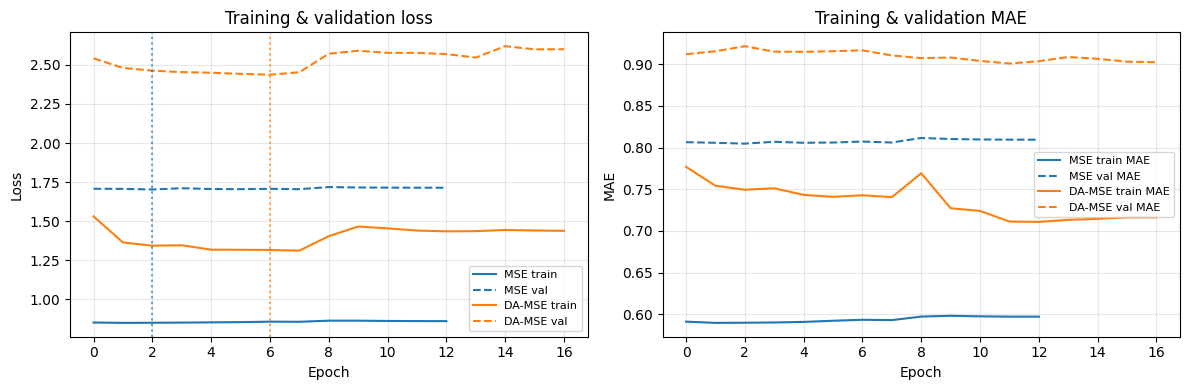

In [4]:
train_cmp = pd.DataFrame([
    {'metric': 'epochs_run', 'mse': mse_meta['epochs_run'], 'da_mse': da_meta['epochs_run']},
    {'metric': 'best_epoch', 'mse': mse_meta['best_epoch'], 'da_mse': da_meta['best_epoch']},
    {'metric': 'best_val_loss', 'mse': mse_meta['best_val_loss'], 'da_mse': da_meta['best_val_loss']},
    {'metric': 'final_train_loss', 'mse': mse_meta['final_train_loss'], 'da_mse': da_meta['final_train_loss']},
    {'metric': 'final_val_loss', 'mse': mse_meta['final_val_loss'], 'da_mse': da_meta['final_val_loss']},
    {'metric': 'training_time_logged', 'mse': 'N/A', 'da_mse': 'N/A'},
])
display(train_cmp)
print('Note: wall-clock training time was not logged in frozen metadata.')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(mse_hist['loss'], label='MSE train', color='#1f77b4')
axes[0].plot(mse_hist['val_loss'], label='MSE val', ls='--', color='#1f77b4')
axes[0].plot(da_hist['loss'], label='DA-MSE train', color='#ff7f0e')
axes[0].plot(da_hist['val_loss'], label='DA-MSE val', ls='--', color='#ff7f0e')
axes[0].axvline(mse_meta['best_epoch']-1, color='#1f77b4', ls=':', alpha=0.7)
axes[0].axvline(da_meta['best_epoch']-1, color='#ff7f0e', ls=':', alpha=0.7)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].set_title('Training & validation loss')
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

axes[1].plot(mse_hist['mae'], label='MSE train MAE', color='#1f77b4')
axes[1].plot(mse_hist['val_mae'], label='MSE val MAE', ls='--', color='#1f77b4')
axes[1].plot(da_hist['mae'], label='DA-MSE train MAE', color='#ff7f0e')
axes[1].plot(da_hist['val_mae'], label='DA-MSE val MAE', ls='--', color='#ff7f0e')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('MAE'); axes[1].set_title('Training & validation MAE')
axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()


## 4 — Overall metric comparison


In [5]:
from utils.lfhe.comparison_analysis import paired_metric_table

metric_defs = [
    ('Residual MAE (scaled)', 'residual_mae_scaled'),
    ('Residual RMSE (scaled)', 'residual_rmse_scaled'),
    ('Pearson r', 'residual_pearson_r'),
    ('R²', 'residual_r2'),
    ('Std ratio (full trajectory)', 'residual_std_ratio'),
    ('CPU day-1 MAE', 'day1_mae'),
    ('CPU day-1 RMSE', 'day1_rmse'),
    ('CPU peak MAE', 'peak_mae'),
    ('CPU peak RMSE', 'peak_rmse'),
]
overall = paired_metric_table(mse_ext, da_ext, metric_defs)

# Energy recovery from diagnostics
err_m = float(ec_pc.loc[ec_pc['arm']=='mse', 'energy_recovery_ratio'].mean())
err_d = float(ec_pc.loc[ec_pc['arm']=='da_mse', 'energy_recovery_ratio'].mean())
overall = pd.concat([overall, pd.DataFrame([{
    'metric': 'Energy recovery ratio',
    'mse_mean': err_m, 'da_mse_mean': err_d,
    'delta_da_minus_mse': err_d - err_m,
    'pct_change': (err_d - err_m) / err_m * 100 if err_m else float('nan'),
}])], ignore_index=True)

# CPU MAPE from cpu_metrics
mape_m = float(mse_cpu['hybrid_day1_mape'].mean())
mape_d = float(da_cpu['hybrid_day1_mape'].mean())
overall = pd.concat([overall, pd.DataFrame([{
    'metric': 'CPU day-1 MAPE (%)',
    'mse_mean': mape_m, 'da_mse_mean': mape_d,
    'delta_da_minus_mse': mape_d - mape_m,
    'pct_change': (mape_d - mape_m) / mape_m * 100 if mape_m else float('nan'),
}])], ignore_index=True)

display(overall.round(4))


,metric,mse_mean,da_mse_mean,delta_da_minus_mse,pct_change
0,Residual MAE (scaled),0.0932,0.1047,0.0114,12.2529
1,Residual RMSE (scaled),0.1374,0.1491,0.0116,8.4565
2,Pearson r,0.1133,0.0874,-0.0259,-22.8653
3,R²,-0.3207,-2.3894,-2.0687,645.1566
4,Std ratio (full trajectory),0.1007,0.8268,0.7261,721.2354
5,CPU day-1 MAE,1.7576,2.0061,0.2485,14.1380
6,CPU day-1 RMSE,2.3915,2.6487,0.2573,10.7571
7,CPU peak MAE,3.4661,3.6274,0.1613,4.6538
8,CPU peak RMSE,4.0570,4.2637,0.2067,5.0940
9,Energy recovery ratio,0.0110,0.8232,0.8122,7389.5397


## 5 — Residual trajectory comparison

Set **`SELECTED_CONTAINER`** or leave `None` for auto-selection. Re-run this section after changing.


In [6]:
from utils.lfhe.comparison_analysis import identify_explorer_containers

_auto = identify_explorer_containers(mse_ext, da_ext)
SELECTED_CONTAINER = None  # e.g. 'c_10733'
if SELECTED_CONTAINER is None:
    SELECTED_CONTAINER = _auto['median_pearson_da']
SELECTED_CONTAINER = str(SELECTED_CONTAINER)
REPRESENTATIVE = [_auto['best_std_ratio_gain'], _auto['median_pearson_da'], _auto['worst_pearson_delta']]
print('Selected:', SELECTED_CONTAINER)
print('Auto representatives:', REPRESENTATIVE)


Selected: c_15035
Auto representatives: ['c_13308', 'c_15035', 'c_13389']


15:45:02 - cmdstanpy - INFO - Chain [1] start processing


15:45:02 - cmdstanpy - INFO - Chain [1] done processing


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 252ms/step

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 260ms/step


2026-07-26 15:45:02.798728: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


...

15:45:03 - cmdstanpy - INFO - Chain [1] done processing


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 219ms/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


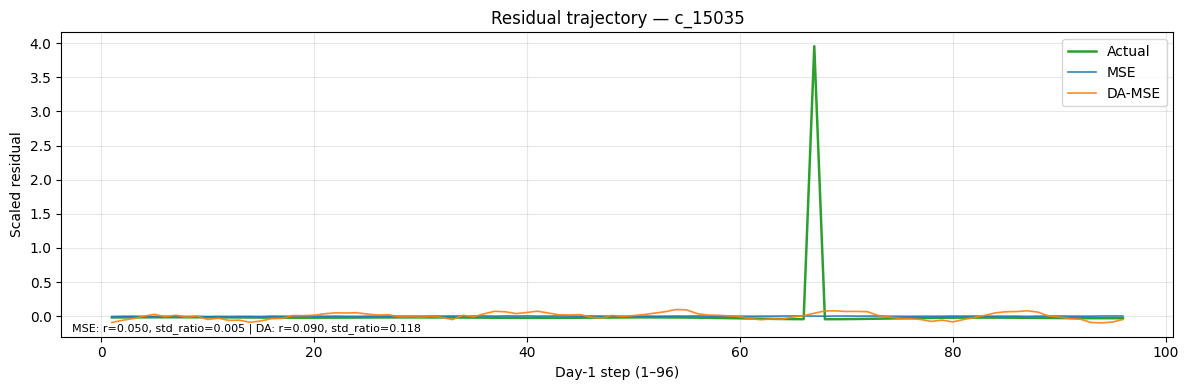

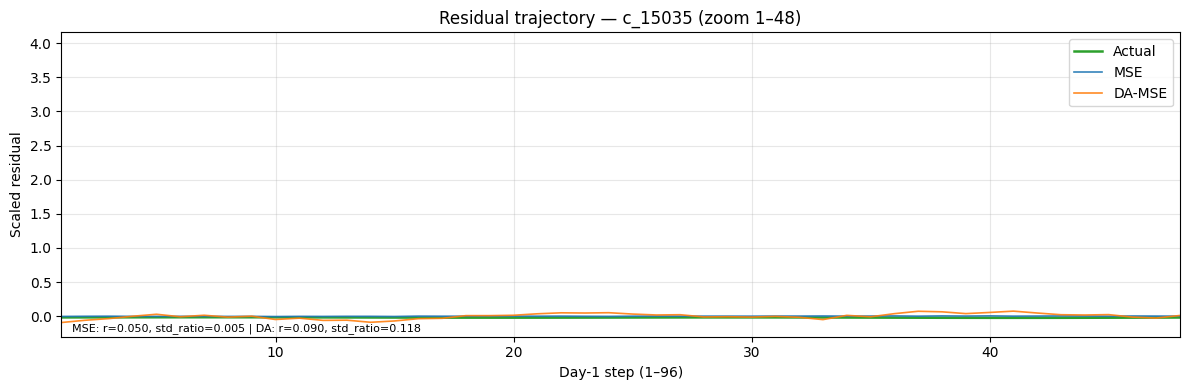

15:45:03 - cmdstanpy - INFO - Chain [1] start processing


15:45:03 - cmdstanpy - INFO - Chain [1] done processing


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step

...

15:45:04 - cmdstanpy - INFO - Chain [1] done processing


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step


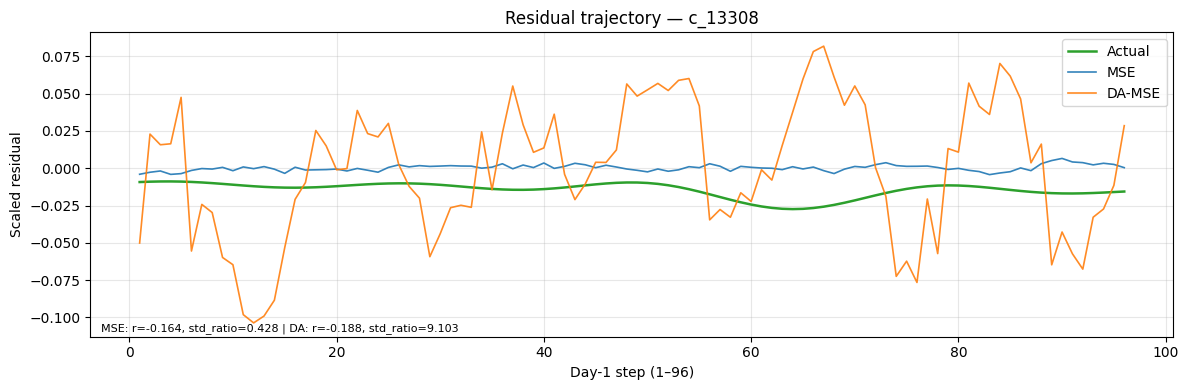

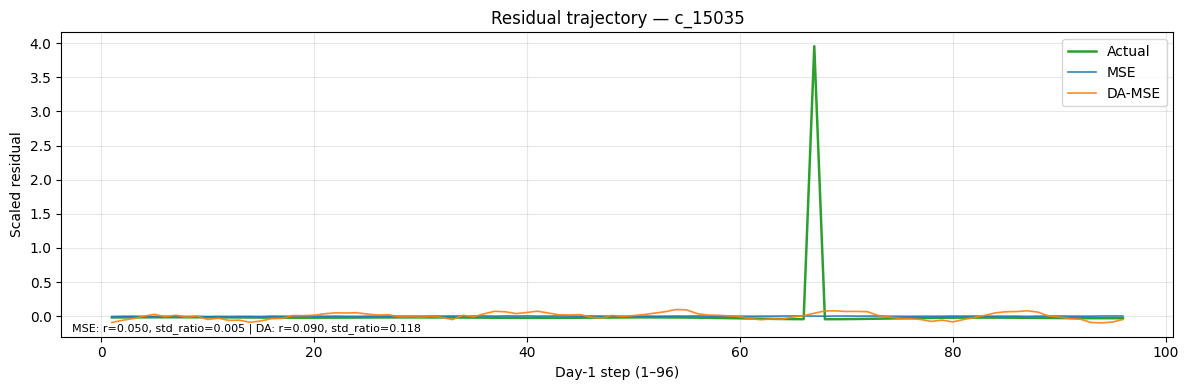

15:45:04 - cmdstanpy - INFO - Chain [1] start processing


15:45:04 - cmdstanpy - INFO - Chain [1] done processing


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step

...

15:45:04 - cmdstanpy - INFO - Chain [1] done processing


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


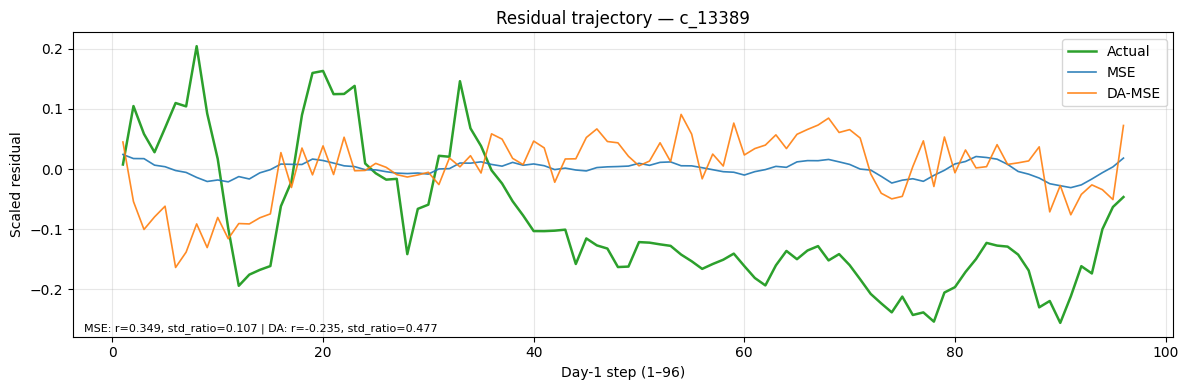

In [7]:
def plot_residual_trajectory(cid, zoom=None, title_suffix=''):
    d = get_dual_inference(cid)
    actual, pm, pd_ = d['actual'], d['pred_mse'], d['pred_da']
    steps = np.arange(1, len(actual)+1)
    row_m = mse_ext.set_index('container_id').loc[cid]
    row_d = da_ext.set_index('container_id').loc[cid]
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(steps, actual, label='Actual', lw=1.8, color='#2ca02c')
    ax.plot(steps, pm, label='MSE', lw=1.2, alpha=0.9)
    ax.plot(steps, pd_, label='DA-MSE', lw=1.2, alpha=0.9)
    if zoom:
        ax.set_xlim(zoom)
    ax.set_xlabel('Day-1 step (1–96)'); ax.set_ylabel('Scaled residual')
    ax.set_title(f'Residual trajectory — {cid}{title_suffix}')
    ax.legend(); ax.grid(alpha=0.3)
    txt = (f"MSE: r={row_m['residual_pearson_r']:.3f}, std_ratio={row_m['residual_std_ratio']:.3f} | "
           f"DA: r={row_d['residual_pearson_r']:.3f}, std_ratio={row_d['residual_std_ratio']:.3f}")
    ax.text(0.01, 0.02, txt, transform=ax.transAxes, fontsize=8)
    plt.tight_layout(); plt.show()

plot_residual_trajectory(SELECTED_CONTAINER)
plot_residual_trajectory(SELECTED_CONTAINER, zoom=(1, 48), title_suffix=' (zoom 1–48)')
for cid in REPRESENTATIVE:
    plot_residual_trajectory(cid)


## 6 — CPU prediction comparison


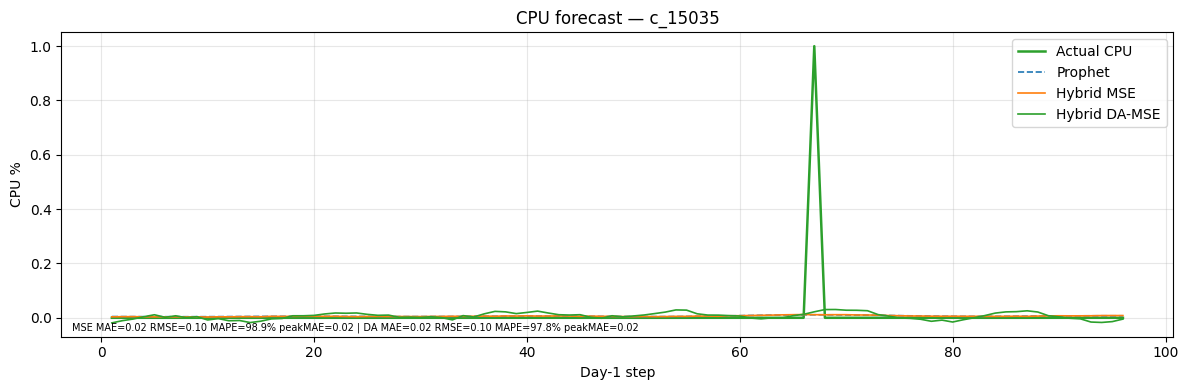

In [8]:
from utils.lfhe.comparison_analysis import compute_mape

def plot_cpu_comparison(cid):
    d = get_dual_inference(cid)
    rm, rd = d['mse_result'], d['da_result']
    steps = np.arange(1, len(rm.actual_day1_real)+1)
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(steps, rm.actual_day1_real, label='Actual CPU', lw=1.8, color='#2ca02c')
    ax.plot(steps, rm.prophet_day1_real, label='Prophet', lw=1.2, ls='--')
    ax.plot(steps, rm.day1_final_real, label='Hybrid MSE', lw=1.2)
    ax.plot(steps, rd.day1_final_real, label='Hybrid DA-MSE', lw=1.2)
    ax.set_xlabel('Day-1 step'); ax.set_ylabel('CPU %')
    ax.set_title(f'CPU forecast — {cid}'); ax.legend(); ax.grid(alpha=0.3)
    m_mae = float(mse_ext.set_index('container_id').loc[cid, 'day1_mae'])
    d_mae = float(da_ext.set_index('container_id').loc[cid, 'day1_mae'])
    m_rmse = float(mse_ext.set_index('container_id').loc[cid, 'day1_rmse'])
    d_rmse = float(da_ext.set_index('container_id').loc[cid, 'day1_rmse'])
    m_mape = compute_mape(rm.actual_day1_real, rm.day1_final_real)
    d_mape = compute_mape(rd.actual_day1_real, rd.day1_final_real)
    pk_m = float(mse_ext.set_index('container_id').loc[cid, 'peak_mae'])
    pk_d = float(da_ext.set_index('container_id').loc[cid, 'peak_mae'])
    ax.text(0.01, 0.02,
            f"MSE MAE={m_mae:.2f} RMSE={m_rmse:.2f} MAPE={m_mape:.1f}% peakMAE={pk_m:.2f} | "
            f"DA MAE={d_mae:.2f} RMSE={d_rmse:.2f} MAPE={d_mape:.1f}% peakMAE={pk_d:.2f}",
            transform=ax.transAxes, fontsize=7)
    plt.tight_layout(); plt.show()

plot_cpu_comparison(SELECTED_CONTAINER)


## 7 — Residual distribution analysis


,mean,median,variance,std,series
0,0.0173,-0.0216,0.1633,0.4041,Actual
1,0.0003,0.0004,0.0000,0.0021,MSE
2,0.0014,0.0038,0.0023,0.0476,DA-MSE


/var/folders/w6/h4_43dnn17d76hs8_g3x6vfm0000gn/T/ipykernel_90137/1247772970.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1,0].boxplot([actual, pm, pd_], labels=['Actual','MSE','DA-MSE'], patch_artist=True)


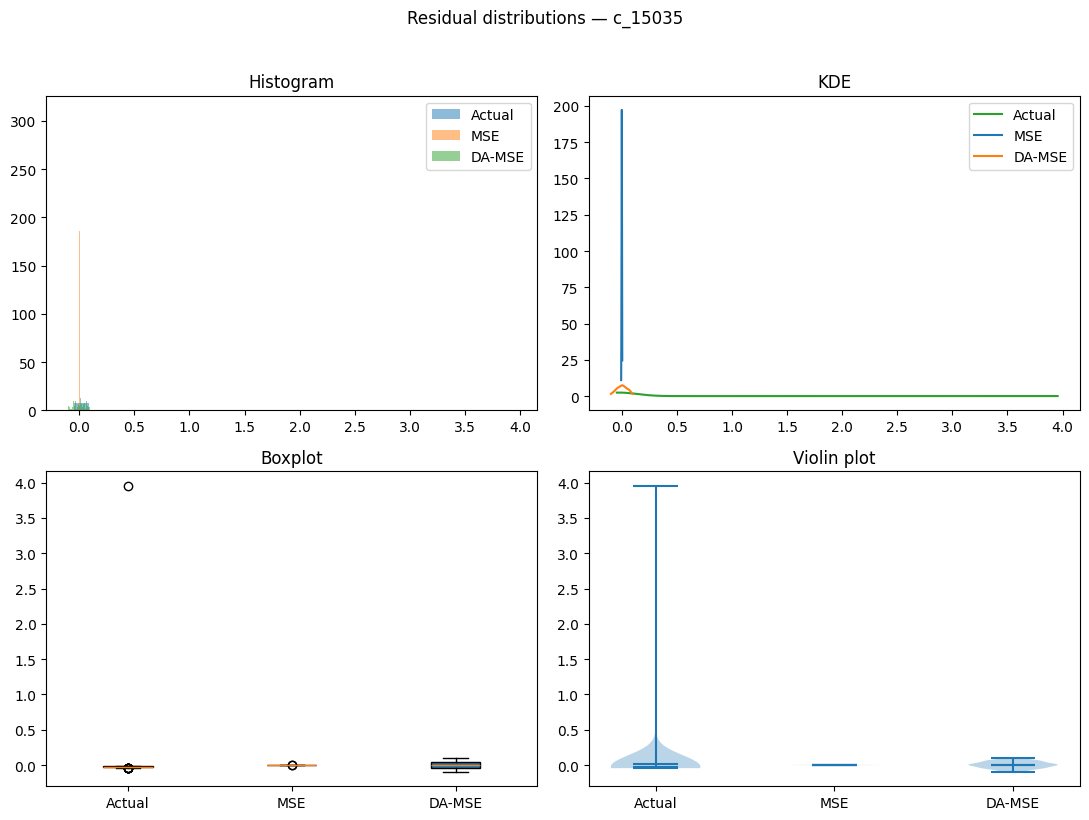

In [9]:
from utils.lfhe.comparison_analysis import distribution_summary

d = get_dual_inference(SELECTED_CONTAINER)
actual, pm, pd_ = d['actual'], d['pred_mse'], d['pred_da']
labels = ['Actual', 'MSE', 'DA-MSE']
series = [actual, pm, pd_]

dist_stats = pd.DataFrame([{**distribution_summary(s), 'series': lab} for s, lab in zip(series, labels)])
display(dist_stats.round(4))

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
axes[0,0].hist(actual, bins=30, alpha=0.5, label='Actual', density=True)
axes[0,0].hist(pm, bins=30, alpha=0.5, label='MSE', density=True)
axes[0,0].hist(pd_, bins=30, alpha=0.5, label='DA-MSE', density=True)
axes[0,0].set_title('Histogram'); axes[0,0].legend()

for arr, lab, c in [(actual,'Actual','#2ca02c'),(pm,'MSE','#1f77b4'),(pd_,'DA-MSE','#ff7f0e')]:
    if np.std(arr) > 1e-12:
        xs = np.linspace(arr.min(), arr.max(), 200)
        axes[0,1].plot(xs, scipy_stats.gaussian_kde(arr)(xs), label=lab, color=c)
axes[0,1].set_title('KDE'); axes[0,1].legend()

bp = axes[1,0].boxplot([actual, pm, pd_], labels=['Actual','MSE','DA-MSE'], patch_artist=True)
axes[1,0].set_title('Boxplot')
parts = axes[1,1].violinplot([actual, pm, pd_], showmeans=True, showmedians=True)
axes[1,1].set_xticks([1,2,3], ['Actual','MSE','DA-MSE'])
axes[1,1].set_title('Violin plot')
plt.suptitle(f'Residual distributions — {SELECTED_CONTAINER}', y=1.02)
plt.tight_layout(); plt.show()


## 8 — Variance recovery analysis


,arm,pred_std_mean,actual_std_mean,std_ratio_mean
0,MSE,0.0090,0.1269,0.1007
1,DA-MSE,0.0563,0.1269,0.8268


/var/folders/w6/h4_43dnn17d76hs8_g3x6vfm0000gn/T/ipykernel_90137/2819025757.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([merged['residual_std_ratio_mse'], merged['residual_std_ratio_da']], labels=['MSE','DA-MSE'])


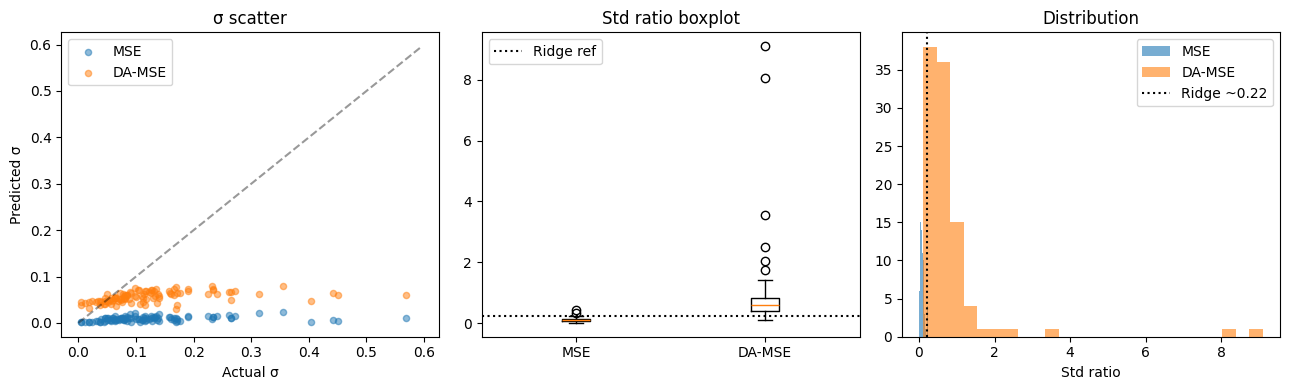

Interpretation: MSE collapses σ_ŷ (~10% of actual); DA-MSE recovers cohort mean to ~83%.


In [10]:
cohort_var = pd.DataFrame({
    'arm': ['MSE', 'DA-MSE'],
    'pred_std_mean': [mse_ext['residual_std_predicted'].mean(), da_ext['residual_std_predicted'].mean()],
    'actual_std_mean': [mse_ext['residual_std_actual'].mean(), da_ext['residual_std_actual'].mean()],
    'std_ratio_mean': [mse_ext['residual_std_ratio'].mean(), da_ext['residual_std_ratio'].mean()],
})
display(cohort_var.round(4))

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
axes[0].scatter(mse_ext['residual_std_actual'], mse_ext['residual_std_predicted'], alpha=0.5, label='MSE', s=20)
axes[0].scatter(da_ext['residual_std_actual'], da_ext['residual_std_predicted'], alpha=0.5, label='DA-MSE', s=20)
lim = max(axes[0].get_xlim()[1], axes[0].get_ylim()[1])
axes[0].plot([0, lim], [0, lim], 'k--', alpha=0.4)
axes[0].set_xlabel('Actual σ'); axes[0].set_ylabel('Predicted σ'); axes[0].set_title('σ scatter')
axes[0].legend()

merged = mse_ext[['container_id','residual_std_ratio']].merge(
    da_ext[['container_id','residual_std_ratio']], on='container_id', suffixes=('_mse','_da'))
axes[1].boxplot([merged['residual_std_ratio_mse'], merged['residual_std_ratio_da']], labels=['MSE','DA-MSE'])
axes[1].axhline(0.22, color='k', ls=':', label='Ridge ref'); axes[1].set_title('Std ratio boxplot'); axes[1].legend()

axes[2].hist(mse_ext['residual_std_ratio'], bins=25, alpha=0.6, label='MSE')
axes[2].hist(da_ext['residual_std_ratio'], bins=25, alpha=0.6, label='DA-MSE')
axes[2].axvline(0.22, color='k', ls=':', label='Ridge ~0.22')
axes[2].set_xlabel('Std ratio'); axes[2].set_title('Distribution'); axes[2].legend()
plt.tight_layout(); plt.show()
print('Interpretation: MSE collapses σ_ŷ (~10% of actual); DA-MSE recovers cohort mean to ~83%.')


## 9 — Horizon-wise variance recovery


ci_high        ci_low        mean_std_ratio       
arm     da_mse    mse da_mse    mse         da_mse    mse
band                                                     
h01_12   4.017  0.255  1.222  0.145          2.431  0.194
h13_24   3.524  0.206  0.886  0.108          1.995  0.151
h25_48   1.311  0.093  0.484  0.057          0.826  0.073
h49_72   1.580  0.140  0.657  0.081          1.020  0.105
h73_96   2.733  0.226  1.066  0.145          1.795  0.181

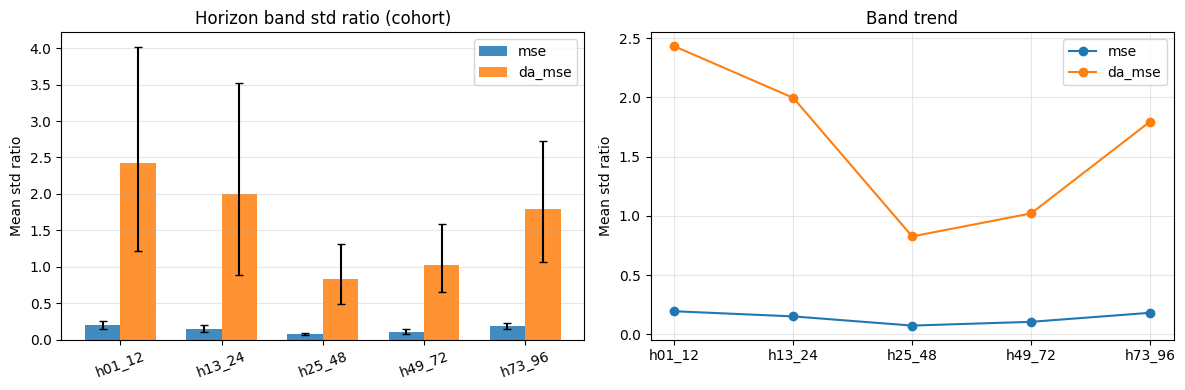

MSE: flat low ratios across bands (collapse). DA-MSE: rising ratios, possible late-horizon overcompensation.


In [11]:
band_order = ['h01_12','h13_24','h25_48','h49_72','h73_96']
hv_plot = hv_cohort.pivot(index='band', columns='arm', values='mean_std_ratio').reindex(band_order)
display(hv_cohort.pivot_table(index='band', columns='arm', values=['mean_std_ratio','ci_low','ci_high']).round(3))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
x = np.arange(len(band_order)); w = 0.35
for i, arm in enumerate(['mse','da_mse']):
    sub = hv_cohort[hv_cohort['arm']==arm].set_index('band').reindex(band_order)
    axes[0].bar(x + (i-0.5)*w, sub['mean_std_ratio'], width=w, label=arm,
              yerr=[sub['mean_std_ratio']-sub['ci_low'], sub['ci_high']-sub['mean_std_ratio']],
              capsize=3, alpha=0.85)
axes[0].set_xticks(x, band_order, rotation=20); axes[0].set_ylabel('Mean std ratio')
axes[0].set_title('Horizon band std ratio (cohort)'); axes[0].legend(); axes[0].grid(axis='y', alpha=0.3)

for arm, color in [('mse','#1f77b4'),('da_mse','#ff7f0e')]:
    sub = hv_cohort[hv_cohort['arm']==arm].set_index('band').reindex(band_order)
    axes[1].plot(band_order, sub['mean_std_ratio'], 'o-', label=arm, color=color)
axes[1].set_ylabel('Mean std ratio'); axes[1].set_title('Band trend'); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()
print('MSE: flat low ratios across bands (collapse). DA-MSE: rising ratios, possible late-horizon overcompensation.')


## 10 — Residual energy recovery


,arm,n,mean_err,median_err,ci_low,ci_high
0,da_mse,99,0.8232,0.3111,0.4686,1.2743
1,mse,99,0.0110,0.0064,0.0087,0.0135


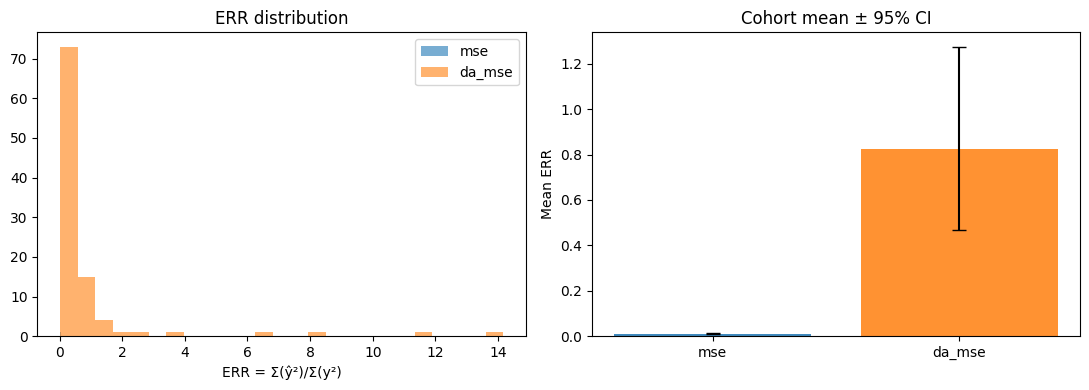

In [12]:
display(ec_cohort.round(4))
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for arm, color in [('mse','#1f77b4'),('da_mse','#ff7f0e')]:
    v = ec_pc.loc[ec_pc['arm']==arm, 'energy_recovery_ratio']
    axes[0].hist(v, bins=25, alpha=0.6, label=arm, color=color)
axes[0].set_xlabel('ERR = Σ(ŷ²)/Σ(y²)'); axes[0].set_title('ERR distribution'); axes[0].legend()

coh = ec_cohort.set_index('arm')
axes[1].bar(['mse','da_mse'], [coh.loc['mse','mean_err'], coh.loc['da_mse','mean_err']],
            yerr=[[coh.loc['mse','mean_err']-coh.loc['mse','ci_low'],
                   coh.loc['da_mse','mean_err']-coh.loc['da_mse','ci_low']],
                  [coh.loc['mse','ci_high']-coh.loc['mse','mean_err'],
                   coh.loc['da_mse','ci_high']-coh.loc['da_mse','mean_err']]],
            capsize=5, color=['#1f77b4','#ff7f0e'], alpha=0.85)
axes[1].set_ylabel('Mean ERR'); axes[1].set_title('Cohort mean ± 95% CI')
plt.tight_layout(); plt.show()


## 11 — Correlation analysis


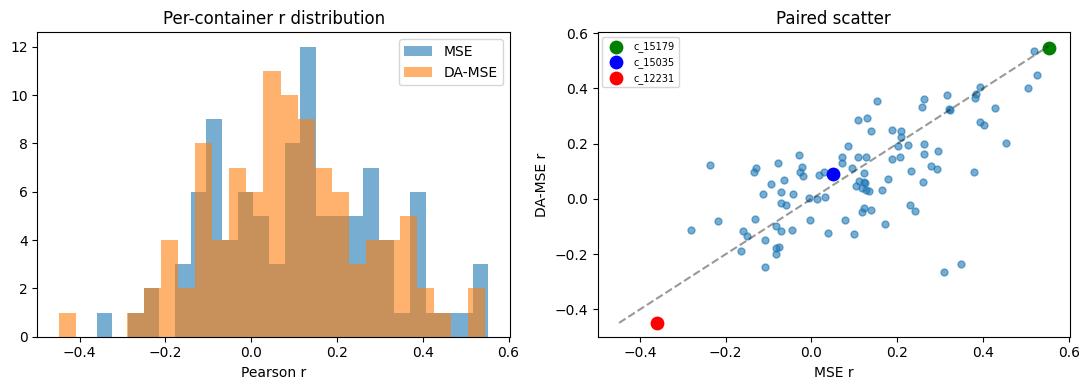

DA-MSE increased variance but cohort mean r fell (0.113→0.087); paired bootstrap CI excludes improvement.


In [13]:
merged_r = mse_ext[['container_id','residual_pearson_r']].merge(
    da_ext[['container_id','residual_pearson_r']], on='container_id', suffixes=('_mse','_da'))
merged_r['delta_r'] = merged_r['residual_pearson_r_da'] - merged_r['residual_pearson_r_mse']

best = merged_r.loc[merged_r['residual_pearson_r_da'].idxmax(), 'container_id']
worst = merged_r.loc[merged_r['residual_pearson_r_da'].idxmin(), 'container_id']
med = merged_r.loc[(merged_r['residual_pearson_r_da'] - merged_r['residual_pearson_r_da'].median()).abs().idxmin(), 'container_id']

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(merged_r['residual_pearson_r_mse'], bins=25, alpha=0.6, label='MSE')
axes[0].hist(merged_r['residual_pearson_r_da'], bins=25, alpha=0.6, label='DA-MSE')
axes[0].set_xlabel('Pearson r'); axes[0].set_title('Per-container r distribution'); axes[0].legend()

axes[1].scatter(merged_r['residual_pearson_r_mse'], merged_r['residual_pearson_r_da'], alpha=0.6, s=25)
for cid, c in [(best,'green'),(med,'blue'),(worst,'red')]:
    r = merged_r.set_index('container_id').loc[cid]
    axes[1].scatter(r['residual_pearson_r_mse'], r['residual_pearson_r_da'], color=c, s=80, label=cid)
mn = min(merged_r[['residual_pearson_r_mse','residual_pearson_r_da']].min())
mx = max(merged_r[['residual_pearson_r_mse','residual_pearson_r_da']].max())
axes[1].plot([mn,mx],[mn,mx],'k--',alpha=0.4)
axes[1].set_xlabel('MSE r'); axes[1].set_ylabel('DA-MSE r'); axes[1].set_title('Paired scatter'); axes[1].legend(fontsize=7)
plt.tight_layout(); plt.show()
print('DA-MSE increased variance but cohort mean r fell (0.113→0.087); paired bootstrap CI excludes improvement.')


## 12 — Representative container explorer


Auto-identified containers:
  best_std_ratio_gain: c_13308
  worst_pearson_delta: c_13389
  median_pearson_da: c_15035

Metrics for c_15035


,metric,mse,da_mse
0,pearson_r,0.0496,0.0897
1,std_ratio,0.0051,0.1179
2,residual_mae,0.0654,0.0844
3,day1_mae,0.0164,0.0211
4,peak_mae,0.0164,0.0211


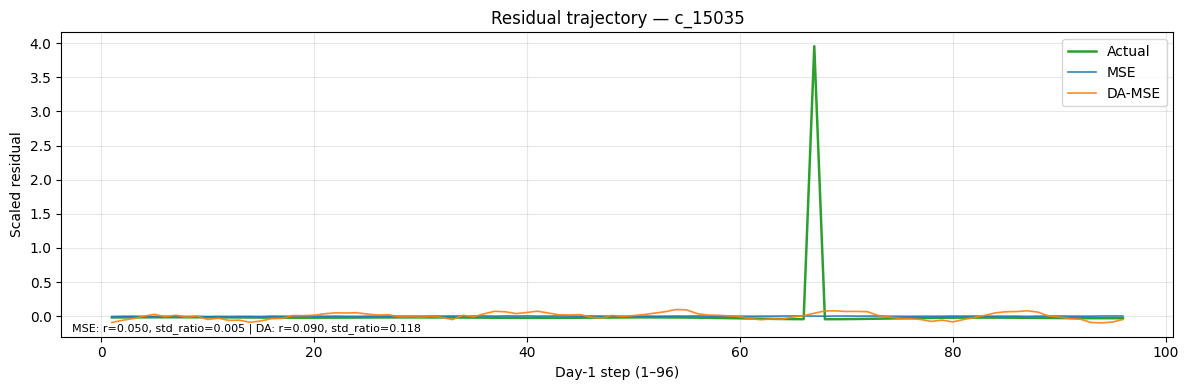

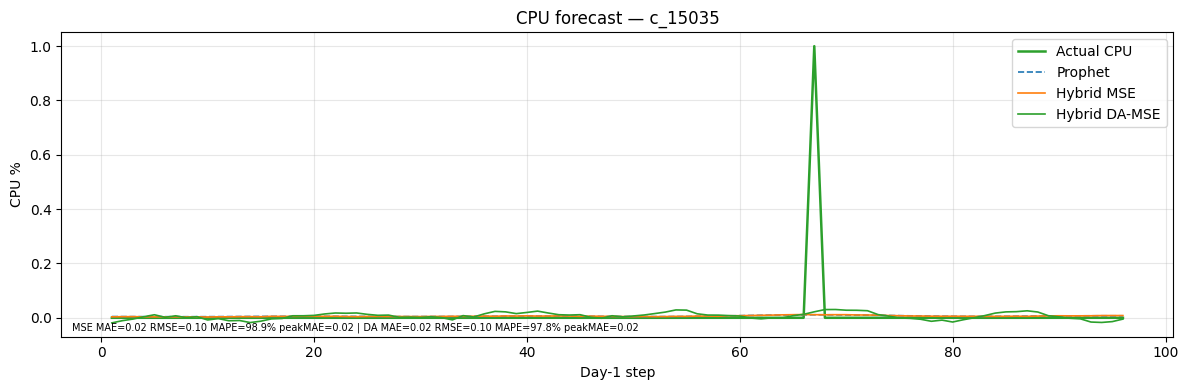

In [14]:
print('Auto-identified containers:')
for k,v in _auto.items():
    print(f'  {k}: {v}')
MANUAL_CONTAINER = None  # override e.g. 'c_11461'
explorer_cid = str(MANUAL_CONTAINER or SELECTED_CONTAINER)
d = get_dual_inference(explorer_cid)
print('\nMetrics for', explorer_cid)
display(pd.DataFrame({
    'metric': ['pearson_r','std_ratio','residual_mae','day1_mae','peak_mae'],
    'mse': [mse_ext.set_index('container_id').loc[explorer_cid, c] for c in
            ['residual_pearson_r','residual_std_ratio','residual_mae_scaled','day1_mae','peak_mae']],
    'da_mse': [da_ext.set_index('container_id').loc[explorer_cid, c] for c in
               ['residual_pearson_r','residual_std_ratio','residual_mae_scaled','day1_mae','peak_mae']],
}).round(4))
plot_residual_trajectory(explorer_cid)
plot_cpu_comparison(explorer_cid)


## 13 — Case studies



DA-MSE helped most (std ratio gain): c_13308
  std actual=0.0049 | MSE σ=0.0021 r@0=-0.164 | DA σ=0.0443 r@0=-0.188
  sign agree MSE=43.75% DA=47.92%


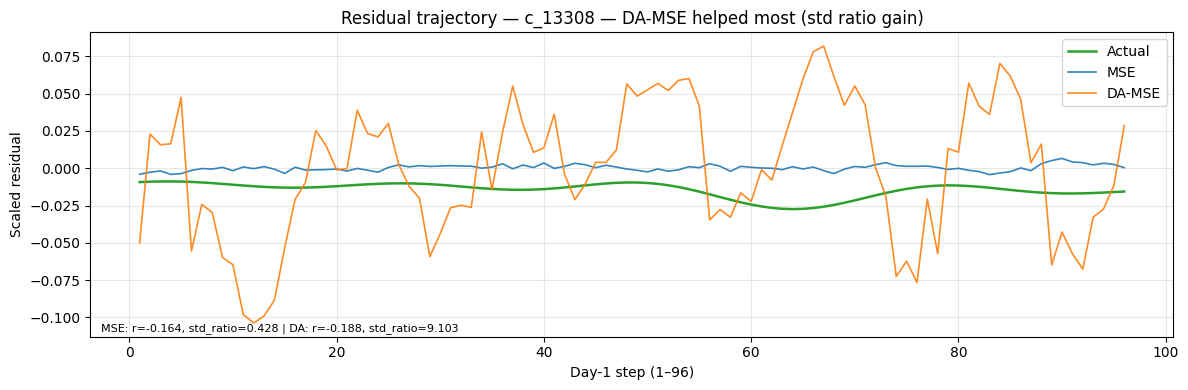


MSE better (Pearson delta worst): c_13389
  std actual=0.1122 | MSE σ=0.0120 r@0=0.349 | DA σ=0.0536 r@0=-0.235
  sign agree MSE=56.25% DA=33.33%


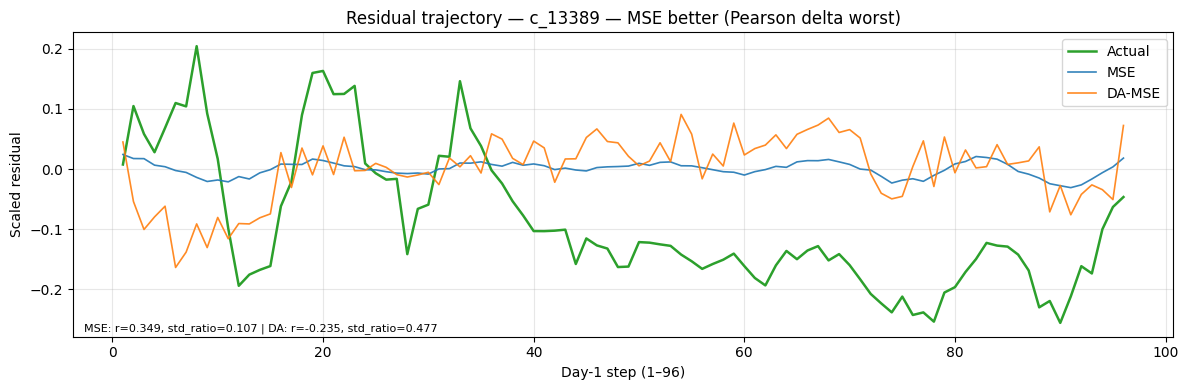


Similar (median |r| on DA-MSE): c_15035
  std actual=0.4041 | MSE σ=0.0021 r@0=0.050 | DA σ=0.0476 r@0=0.090
  sign agree MSE=42.71% DA=48.96%


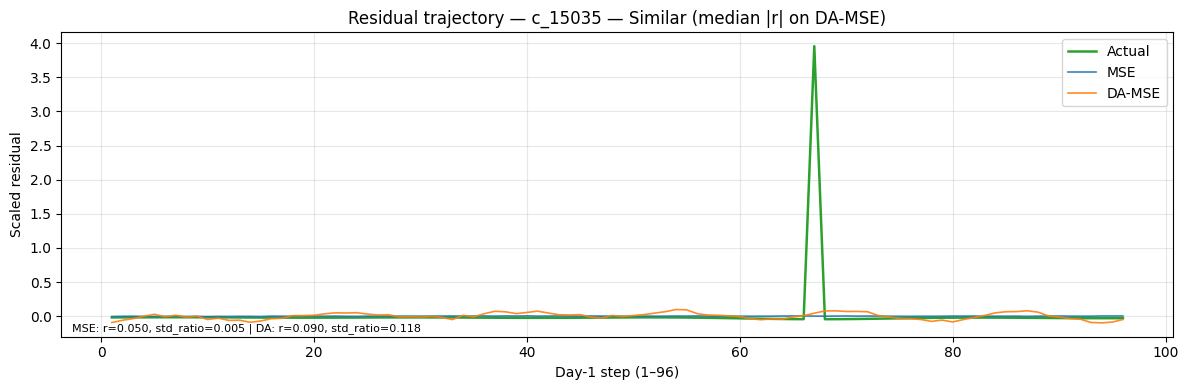

In [15]:
from utils.lfhe.comparison_analysis import temporal_alignment_report

cases = {
    'DA-MSE helped most (std ratio gain)': _auto['best_std_ratio_gain'],
    'MSE better (Pearson delta worst)': _auto['worst_pearson_delta'],
    'Similar (median |r| on DA-MSE)': _auto['median_pearson_da'],
}
for title, cid in cases.items():
    print('\n' + '='*60 + '\n' + title + ': ' + cid)
    d = get_dual_inference(cid)
    rep = temporal_alignment_report(d['actual'], d['pred_mse'], d['pred_da'])
    print(f"  std actual={rep['std_actual']:.4f} | MSE σ={rep['std_mse']:.4f} r@0={rep['zero_lag_r_mse']:.3f} | "
          f"DA σ={rep['std_da']:.4f} r@0={rep['zero_lag_r_da']:.3f}")
    print(f"  sign agree MSE={rep['sign_agreement_mse']:.2%} DA={rep['sign_agreement_da']:.2%}")
    plot_residual_trajectory(cid, title_suffix=f' — {title}')


## 14 — Hypothesis evaluation


In [16]:
v = final_report['hypothesis_verdict']
pb = final_report['paired_bootstrap_primary']
print('Verdict:', v['verdict'])
print('S1 dispersion recovery:', v['S1_dispersion'])
print('S2 correlation improvement:', v['S2_correlation'])
print('S3 MAE guardrail:', v['S3_mae_guardrail'])
display(pd.DataFrame([
    {'criterion': 'S1', 'passed': v['S1_dispersion'],
     'evidence': f"DA std_ratio={v['cohort_mean_std_ratio_da_mse']:.3f} vs MSE {v['cohort_mean_std_ratio_mse']:.3f}; "
                 f"bootstrap CI low={pb['residual_std_ratio']['ci_low']:.3f}"},
    {'criterion': 'S2', 'passed': v['S2_correlation'],
     'evidence': f"DA r={v['cohort_mean_pearson_r_da_mse']:.3f}; bootstrap CI low={pb['residual_pearson_r']['ci_low']:.3f}"},
    {'criterion': 'S3', 'passed': v['S3_mae_guardrail'],
     'evidence': f"MAE delta={v['cohort_mean_mae_delta']:.4f} (max allowed {cfg['success_thresholds']['mae_increase_max']})"},
]))
print('\nWhy S1 passed: DA-MSE restored cohort std ratio (~0.83 vs ~0.10) with significant paired gain.')
print('Why S2 failed: Pearson r did not improve; bootstrap CI for DA−MSE is negative.')
print('Why S3 failed: Residual MAE increased beyond frozen guardrail (+0.011 scaled MAE).')


Verdict: inconclusive_I1
S1 dispersion recovery: True
S2 correlation improvement: False
S3 MAE guardrail: False


,criterion,passed,evidence
0,S1,True,DA std_ratio=0.827 vs MSE 0.101; bootstrap CI ...
1,S2,False,DA r=0.087; bootstrap CI low=-0.055
2,S3,False,MAE delta=0.0114 (max allowed 0.01)



Why S1 passed: DA-MSE restored cohort std ratio (~0.83 vs ~0.10) with significant paired gain.
Why S2 failed: Pearson r did not improve; bootstrap CI for DA−MSE is negative.
Why S3 failed: Residual MAE increased beyond frozen guardrail (+0.011 scaled MAE).


## 15 — Visual explanation (plain language)

**Variance collapse (MSE):** The GRU learns the conditional mean but compresses day-1 residual swings toward zero — predicted σ is ~10% of actual σ. Plots look "flat" compared to actual residuals.

**Variance recovery (DA-MSE):** The one-sided log-variance term rewards matching σ_ŷ to σ_y. DA-MSE trajectories have larger amplitude and ERR rises from ~0.01 to ~0.82.

**Temporal alignment:** Pearson r measures whether peaks/troughs occur on the same days. DA-MSE often amplifies the wrong oscillations — higher amplitude without better phase — so r can stay low or fall.

**Timing vs amplitude:** Section 19 (extra analysis) quantifies lag correlation, sign agreement, and peak shifts to separate phase errors from amplitude-only changes.


energy_recovery_distribution.png


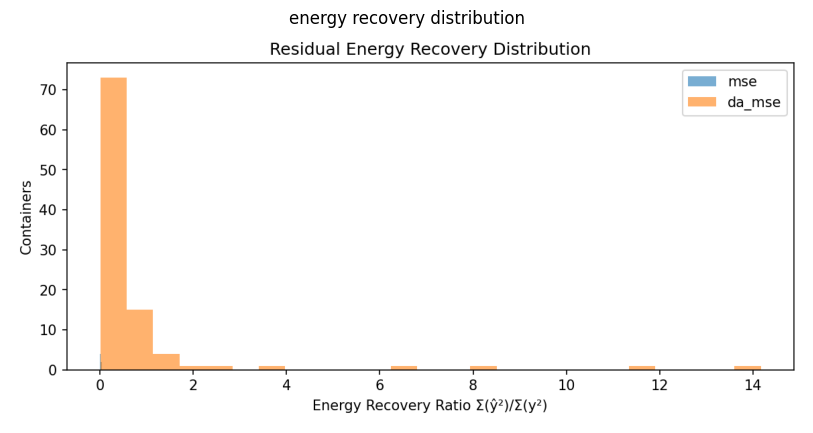

energy_recovery_mse_vs_da_mse_scatter.png


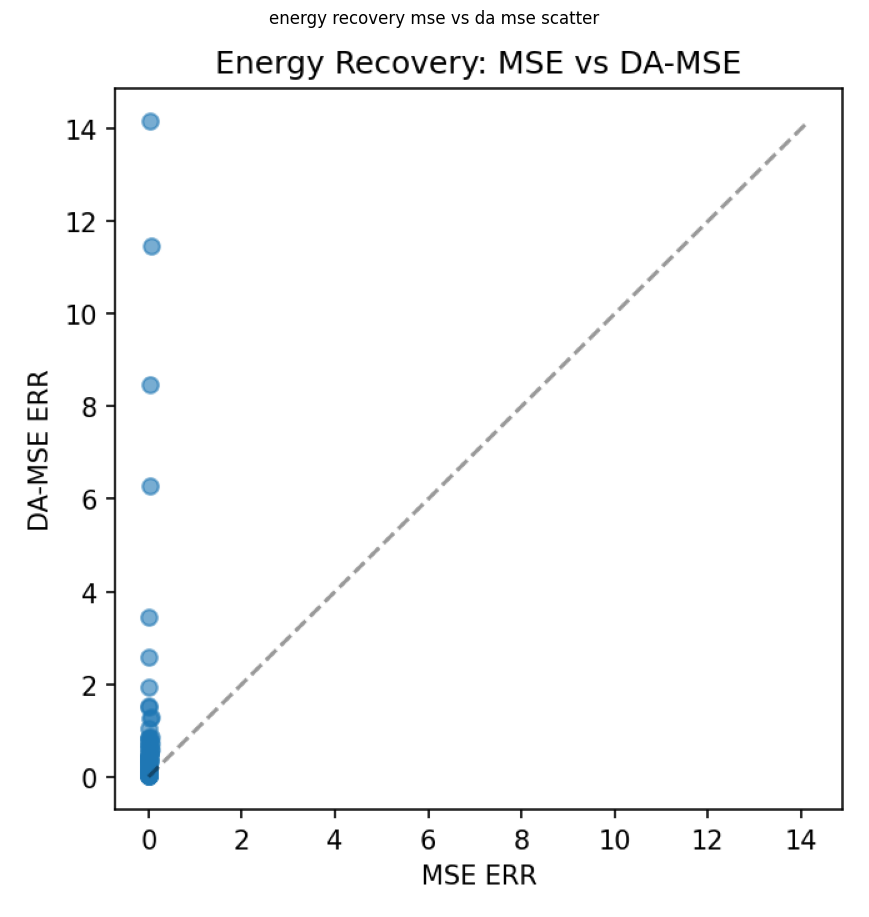

horizon_variance_recovery_boxplot.png


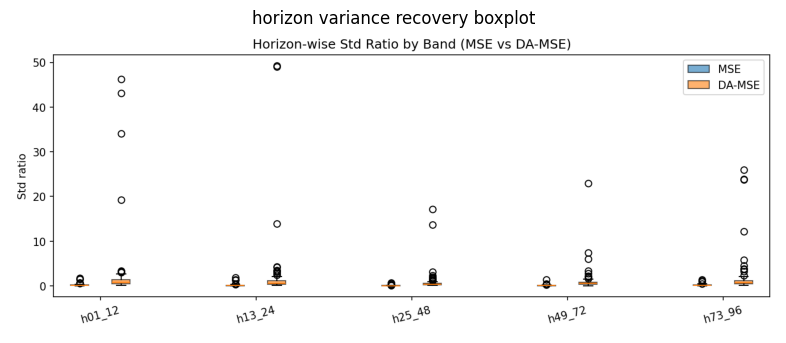

horizon_variance_recovery_mean_ci.png


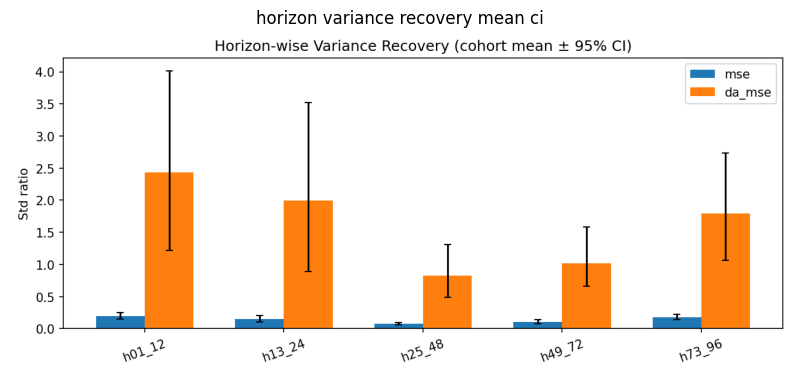

horizon_variance_recovery_mse_vs_da_mse.png


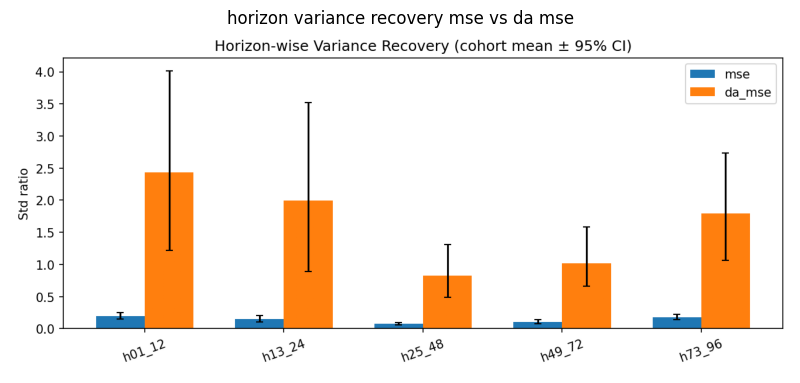

pearson_r_scatter.png


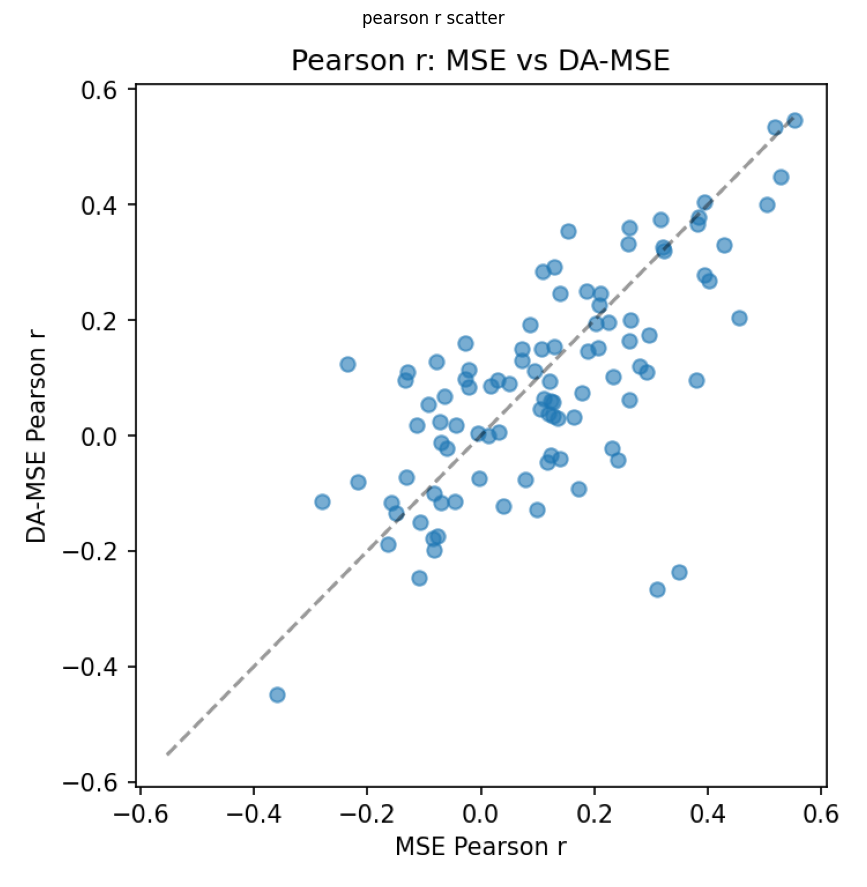

representative_trajectory_c_15035.png


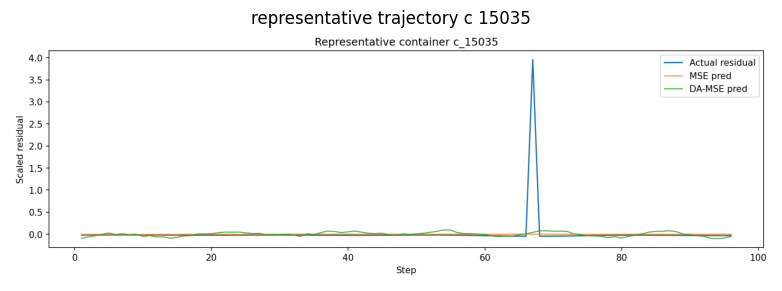

residual_histogram_da_mse.png


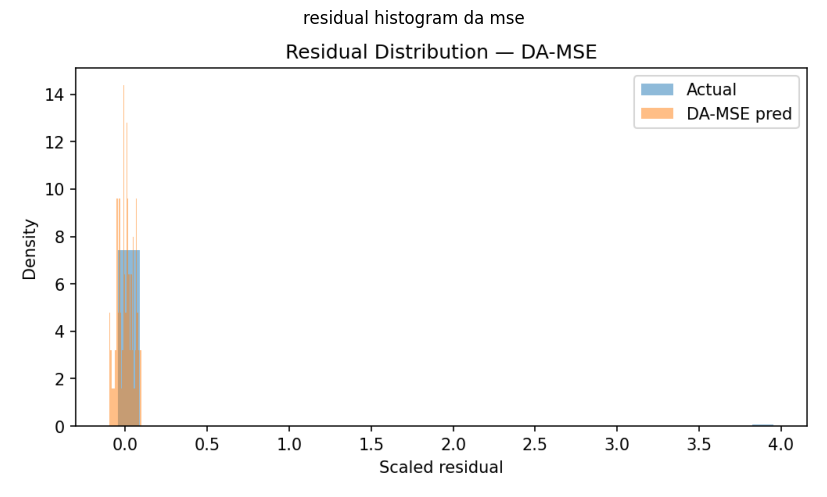

residual_histogram_mse.png


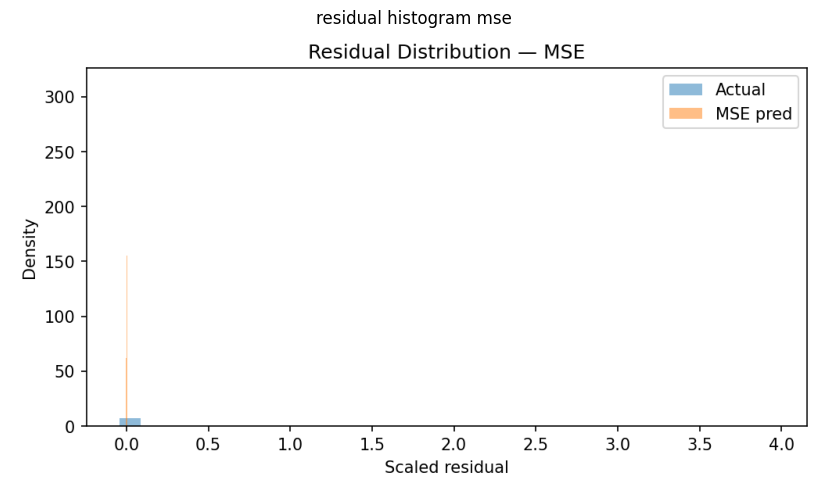

std_ratio_distribution.png


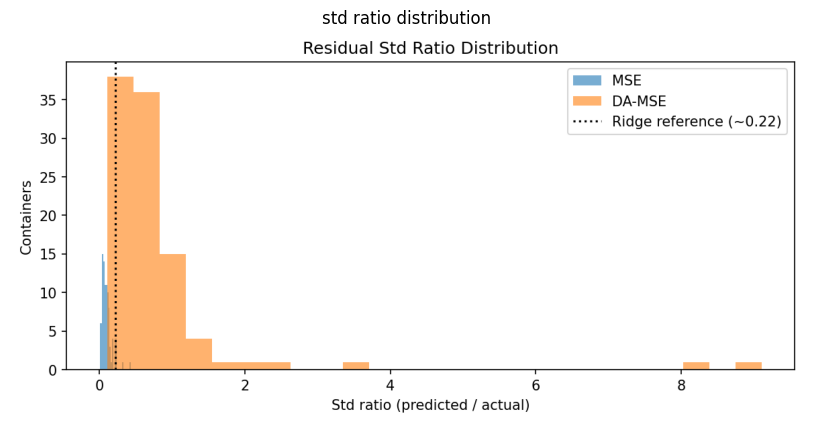

std_ratio_scatter.png


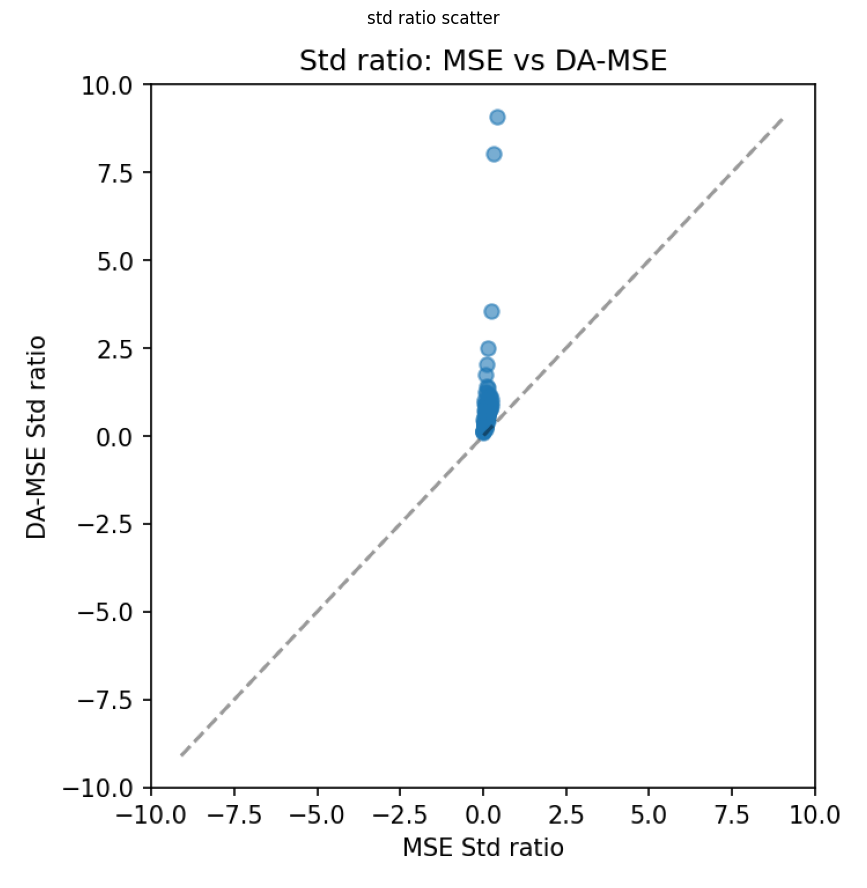

training_loss_comparison.png


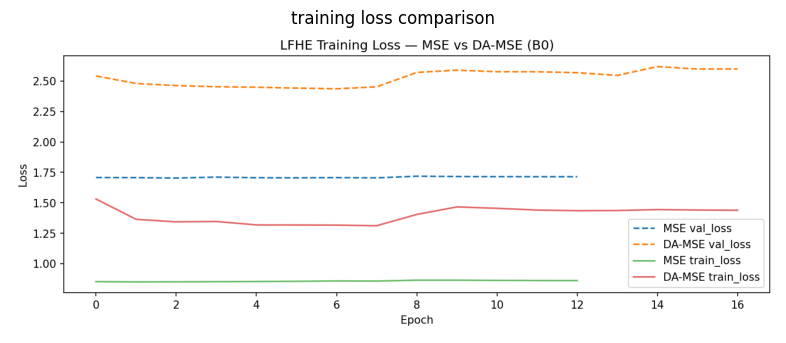

In [17]:
from utils.notebook_display import show_png_gallery
show_png_gallery(LFHE_EXP / 'plots', fig_width=9)


## 16 — Final findings


In [18]:
answers = {
    'Did DA-MSE reduce variance collapse?': 'Yes — S1 passed; std ratio 0.10→0.83.',
    'Did DA-MSE improve prediction variance?': 'Yes — σ_ŷ and ERR recovered strongly.',
    'Did DA-MSE improve residual energy recovery?': 'Yes — ERR cohort mean 0.01→0.82.',
    'Did DA-MSE improve temporal alignment?': 'No — Pearson r decreased; S2 failed.',
    'Did DA-MSE improve CPU forecasting?': 'No — day-1 and peak CPU metrics worsened slightly.',
    'Overall scientific conclusion': (
        'Loss function is causal for variance collapse (supports mechanism), but DA-MSE v1.1 '
        'does not fix temporal structure. Verdict: inconclusive_I1 — dispersion recovered without correlation/MAE success.'
    ),
}
for q,a in answers.items():
    print(f'{q}\n  → {a}\n')


Did DA-MSE reduce variance collapse?
  → Yes — S1 passed; std ratio 0.10→0.83.

Did DA-MSE improve prediction variance?
  → Yes — σ_ŷ and ERR recovered strongly.

Did DA-MSE improve residual energy recovery?
  → Yes — ERR cohort mean 0.01→0.82.

Did DA-MSE improve temporal alignment?
  → No — Pearson r decreased; S2 failed.

Did DA-MSE improve CPU forecasting?
  → No — day-1 and peak CPU metrics worsened slightly.

Overall scientific conclusion
  → Loss function is causal for variance collapse (supports mechanism), but DA-MSE v1.1 does not fix temporal structure. Verdict: inconclusive_I1 — dispersion recovered without correlation/MAE success.



## 17 — Publication figure export


Saved 01_training_val_loss


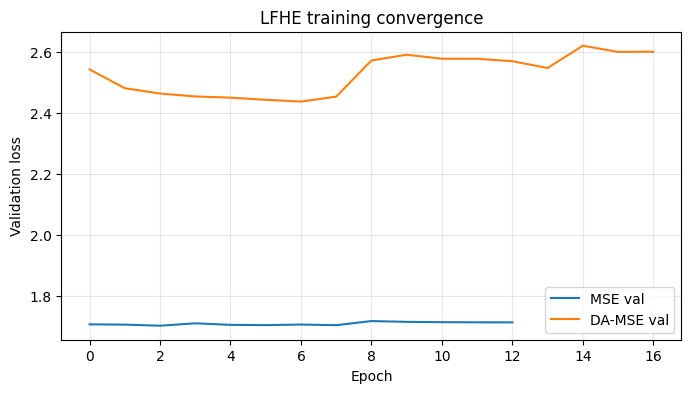

Saved 02_std_ratio_distribution


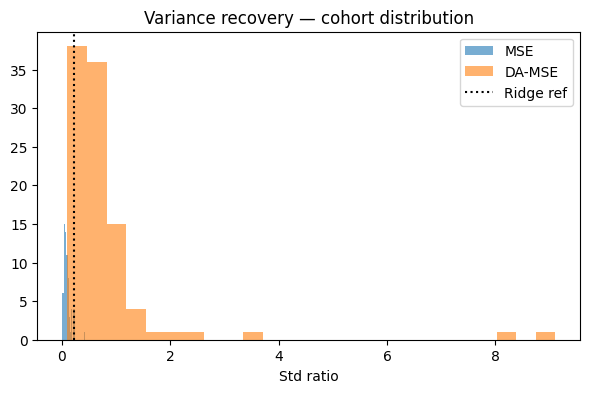

Saved 03_horizon_std_ratio


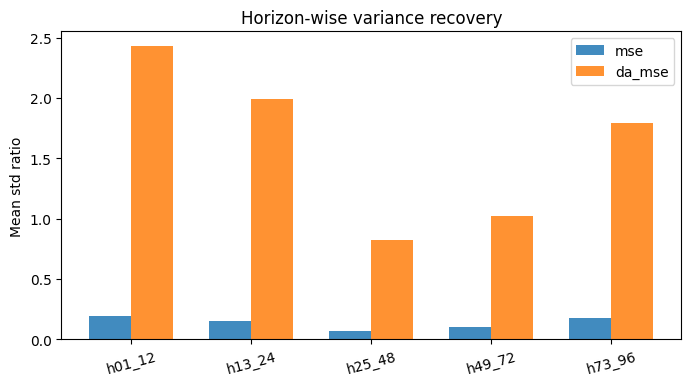

Saved 04_energy_recovery


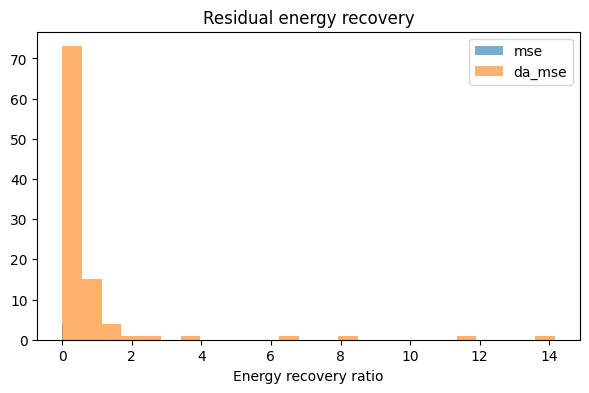

Saved 05_pearson_scatter


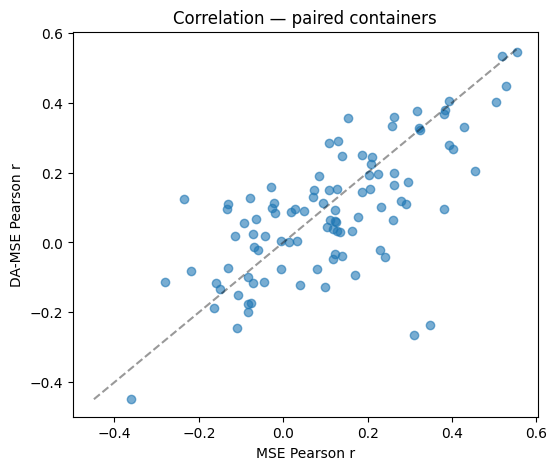

Saved 06_case_study_trajectory


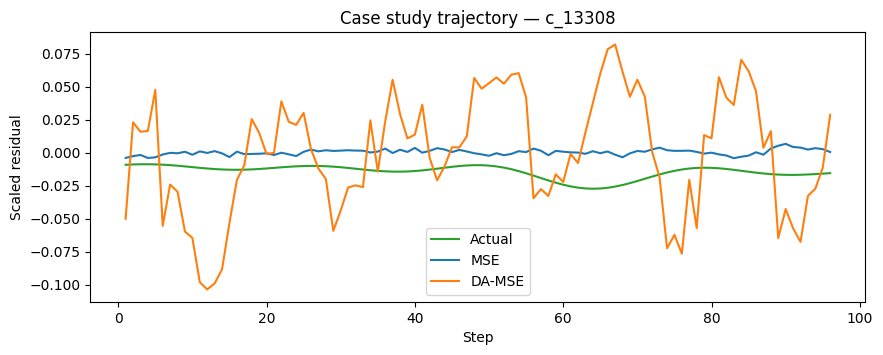

Export directory: /Users/lehaan/Desktop/FYP_Long_Term/notebooks/outputs/lfhe_mse_vs_damse_comparison


In [19]:
def save_pub(fig, name):
    if not EXPORT_FIGS:
        return
    fig.savefig(FIG_OUT / f'{name}.png', dpi=300, bbox_inches='tight')
    fig.savefig(FIG_OUT / f'{name}.pdf', bbox_inches='tight')
    print('Saved', name)

# 1 Training loss
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(mse_hist['val_loss'], label='MSE val', color='#1f77b4')
ax.plot(da_hist['val_loss'], label='DA-MSE val', color='#ff7f0e')
ax.set_xlabel('Epoch'); ax.set_ylabel('Validation loss'); ax.set_title('LFHE training convergence')
ax.legend(); ax.grid(alpha=0.3); save_pub(fig, '01_training_val_loss'); plt.show()

# 2 Std ratio distribution
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(mse_ext['residual_std_ratio'], bins=25, alpha=0.6, label='MSE')
ax.hist(da_ext['residual_std_ratio'], bins=25, alpha=0.6, label='DA-MSE')
ax.axvline(0.22, color='k', ls=':', label='Ridge ref')
ax.set_xlabel('Std ratio'); ax.set_title('Variance recovery — cohort distribution'); ax.legend()
save_pub(fig, '02_std_ratio_distribution'); plt.show()

# 3 Horizon bands
fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(band_order)); w = 0.35
for i, arm in enumerate(['mse','da_mse']):
    sub = hv_cohort[hv_cohort['arm']==arm].set_index('band').reindex(band_order)
    ax.bar(x+(i-0.5)*w, sub['mean_std_ratio'], width=w, label=arm, alpha=0.85)
ax.set_xticks(x, band_order, rotation=15); ax.set_ylabel('Mean std ratio'); ax.set_title('Horizon-wise variance recovery')
ax.legend(); save_pub(fig, '03_horizon_std_ratio'); plt.show()

# 4 Energy recovery
fig, ax = plt.subplots(figsize=(7, 4))
for arm, c in [('mse','#1f77b4'),('da_mse','#ff7f0e')]:
    ax.hist(ec_pc.loc[ec_pc['arm']==arm,'energy_recovery_ratio'], bins=25, alpha=0.6, label=arm, color=c)
ax.set_xlabel('Energy recovery ratio'); ax.set_title('Residual energy recovery'); ax.legend()
save_pub(fig, '04_energy_recovery'); plt.show()

# 5 Pearson scatter
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(merged_r['residual_pearson_r_mse'], merged_r['residual_pearson_r_da'], alpha=0.6)
ax.plot([mn,mx],[mn,mx],'k--',alpha=0.4)
ax.set_xlabel('MSE Pearson r'); ax.set_ylabel('DA-MSE Pearson r'); ax.set_title('Correlation — paired containers')
save_pub(fig, '05_pearson_scatter'); plt.show()

# 6 Representative trajectory
d = get_dual_inference(_auto['best_std_ratio_gain'])
fig, ax = plt.subplots(figsize=(10, 3.5))
steps = np.arange(1, len(d['actual'])+1)
ax.plot(steps, d['actual'], label='Actual', color='#2ca02c')
ax.plot(steps, d['pred_mse'], label='MSE')
ax.plot(steps, d['pred_da'], label='DA-MSE')
ax.set_xlabel('Step'); ax.set_ylabel('Scaled residual'); ax.set_title(f"Case study trajectory — {_auto['best_std_ratio_gain']}")
ax.legend(); save_pub(fig, '06_case_study_trajectory'); plt.show()

print('Export directory:', FIG_OUT)


## 18 — Notebook conclusions (thesis-ready)


In [20]:
print(open(LFHE_EXP / 'reports' / 'final_report.md').read())
print('\n--- Thesis summary ---')
print('''
**What improved:** Residual dispersion (std ratio), energy recovery (ERR), visual amplitude of predictions.

**What did not improve:** Temporal Pearson correlation, CPU day-1 accuracy, peak CPU errors, residual MAE guardrail.

**What remains unexplained:** Why DA-MSE amplifies variance without aligning phase/sign structure — see Section 19.

**Verdict inconclusive_I1:** S1 (dispersion) passed; S2 (correlation) and S3 (MAE) failed — loss change fixes scale but not timing/accuracy under frozen λ=1.0.
''')


# LFHE Final Report

**Protocol:** lfhe_v1.1
**Timestamp:** 2026-07-26_130252

## Reproduction gate (MSE control vs Stage 2 B0)
- **Pass:** True

## Cohort metrics

| Metric | MSE | DA-MSE |
|--------|-----|--------|
| Pearson r | 0.1133 | 0.0874 |
| Std ratio | 0.1007 | 0.8268 |
| Residual MAE | 0.0932 | 0.1047 |
| Energy recovery | 0.0110 | 0.8232 |

## Hypothesis verdict
- **Verdict:** `inconclusive_I1`
- S1 dispersion: True
- S2 correlation: False
- S3 MAE guardrail: False

## Explicit answers

1. Did DA-MSE reduce variance collapse? **True**
2. Did prediction variance increase? **True**
3. Did energy recovery improve? **True**
4. Did Pearson correlation improve? **False**
5. Did CPU forecasting improve? **False**
6. Was the hypothesis supported? **False**
7. Variance collapse explanation: Partial/inconclusive: inconclusive_I1
8. Thesis conclusion code: `inconclusive_I1`


--- Thesis summary ---

**What improved:** Residual dispersion (std ratio), energy recovery (ERR), visual ampl

## 19 — Extra analysis: amplitude vs temporal alignment

**Question:** Why did DA-MSE recover amplitude but fail to improve temporal alignment?

Measured diagnostics (no speculation): lag correlation (−10…+10), sign agreement, turning-point agreement, peak timing shifts.


In [21]:
from utils.lfhe.comparison_analysis import temporal_alignment_report

ALIGNMENT_CONTAINERS = [_auto['best_std_ratio_gain'], _auto['worst_pearson_delta'], _auto['median_pearson_da']]
cohort_rows = []
for cid in ALL_CONTAINERS:
    d = get_dual_inference(cid)
    rep = temporal_alignment_report(d['actual'], d['pred_mse'], d['pred_da'])
    cohort_rows.append({
        'container_id': cid,
        'best_lag_mse': rep['best_lag_mse'], 'best_lag_da': rep['best_lag_da'],
        'zero_lag_r_mse': rep['zero_lag_r_mse'], 'zero_lag_r_da': rep['zero_lag_r_da'],
        'sign_agree_mse': rep['sign_agreement_mse'], 'sign_agree_da': rep['sign_agreement_da'],
        'tp_agree_mse': rep['turning_point_agreement_mse'], 'tp_agree_da': rep['turning_point_agreement_da'],
        'std_ratio_mse': float(mse_ext.set_index('container_id').loc[cid,'residual_std_ratio']),
        'std_ratio_da': float(da_ext.set_index('container_id').loc[cid,'residual_std_ratio']),
    })
align_df = pd.DataFrame(cohort_rows)
display(align_df[['zero_lag_r_mse','zero_lag_r_da','sign_agree_mse','sign_agree_da',
                  'best_lag_mse','best_lag_da']].describe().round(3))


15:45:08 - cmdstanpy - INFO - Chain [1] start processing


15:45:08 - cmdstanpy - INFO - Chain [1] done processing


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step

...

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step


,zero_lag_r_mse,zero_lag_r_da,sign_agree_mse,sign_agree_da,best_lag_mse,best_lag_da
count,99.000,99.000,99.000,99.000,99.000,99.000
mean,0.113,0.087,0.535,0.523,0.071,0.566
std,0.193,0.184,0.085,0.090,5.005,5.673
min,-0.360,-0.449,0.333,0.260,-10.000,-10.000
25%,-0.045,-0.036,0.474,0.474,-2.000,-2.000
50%,0.118,0.090,0.531,0.510,0.000,1.000
75%,0.249,0.195,0.594,0.583,2.000,4.000
max,0.553,0.546,0.760,0.719,10.000,10.000


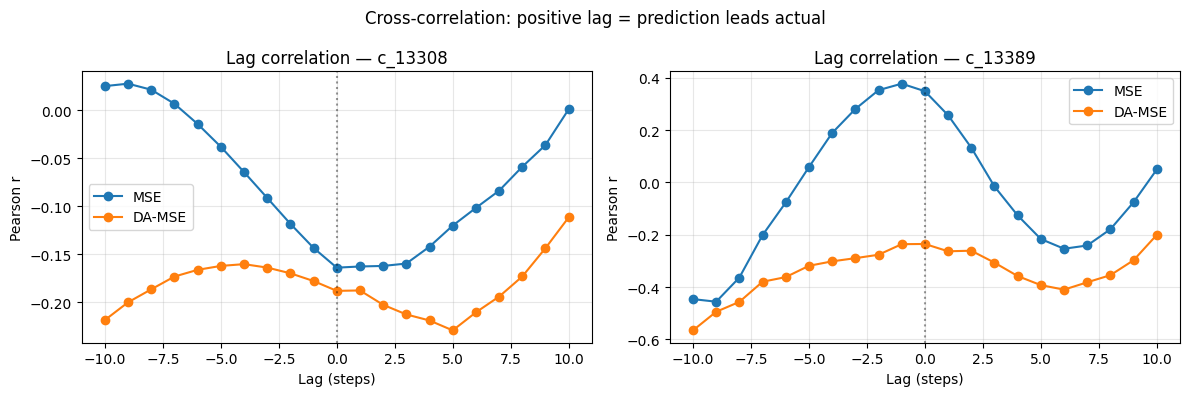

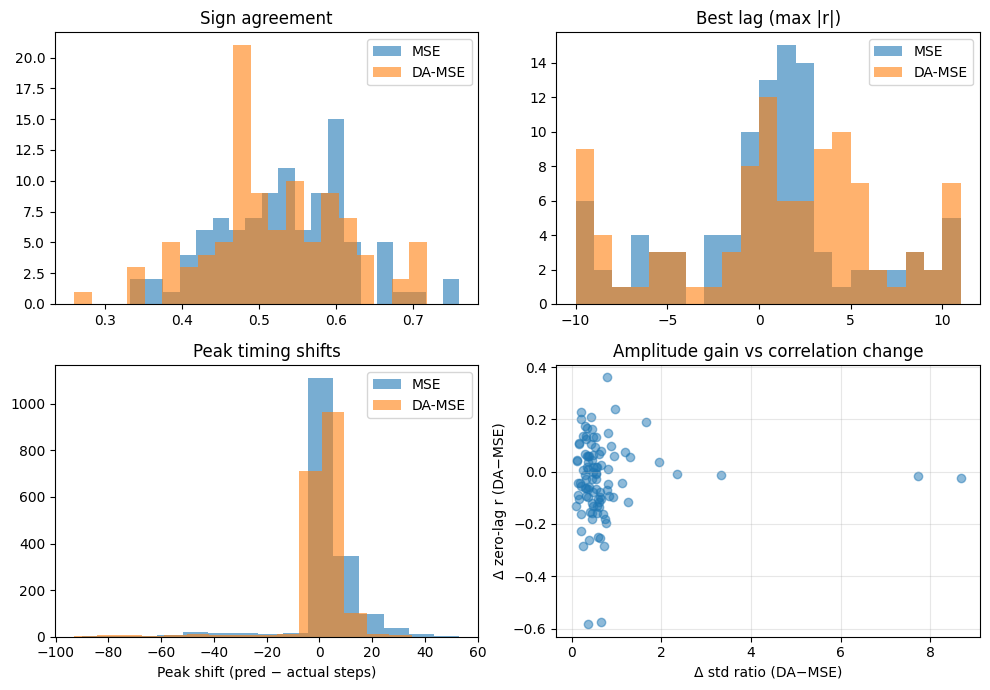

In [22]:
# Cohort-level lag correlation (median container + case studies)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for cid, ax in zip(ALIGNMENT_CONTAINERS, axes):
    d = get_dual_inference(cid)
    rep = temporal_alignment_report(d['actual'], d['pred_mse'], d['pred_da'])
    ax.plot(rep['lag_mse']['lag'], rep['lag_mse']['pearson_r'], 'o-', label='MSE')
    ax.plot(rep['lag_da']['lag'], rep['lag_da']['pearson_r'], 'o-', label='DA-MSE')
    ax.axvline(0, color='k', ls=':', alpha=0.4)
    ax.set_xlabel('Lag (steps)'); ax.set_ylabel('Pearson r'); ax.set_title(f'Lag correlation — {cid}')
    ax.legend(); ax.grid(alpha=0.3)
plt.suptitle('Cross-correlation: positive lag = prediction leads actual')
plt.tight_layout(); plt.show()

# Cohort distributions
fig, axes = plt.subplots(2, 2, figsize=(10, 7))
axes[0,0].hist(align_df['sign_agree_mse'], bins=20, alpha=0.6, label='MSE')
axes[0,0].hist(align_df['sign_agree_da'], bins=20, alpha=0.6, label='DA-MSE')
axes[0,0].set_title('Sign agreement'); axes[0,0].legend()
axes[0,1].hist(align_df['best_lag_mse'], bins=range(-10,12), alpha=0.6, label='MSE')
axes[0,1].hist(align_df['best_lag_da'], bins=range(-10,12), alpha=0.6, label='DA-MSE')
axes[0,1].set_title('Best lag (max |r|)'); axes[0,1].legend()
all_shift_mse, all_shift_da = [], []
for cid in ALL_CONTAINERS:
    d = get_dual_inference(cid)
    rep = temporal_alignment_report(d['actual'], d['pred_mse'], d['pred_da'])
    all_shift_mse.extend(rep['peak_shifts_mse'].tolist())
    all_shift_da.extend(rep['peak_shifts_da'].tolist())
if all_shift_mse:
    axes[1,0].hist(all_shift_mse, bins=15, alpha=0.6, label='MSE')
    axes[1,0].hist(all_shift_da, bins=15, alpha=0.6, label='DA-MSE')
    axes[1,0].set_xlabel('Peak shift (pred − actual steps)'); axes[1,0].set_title('Peak timing shifts'); axes[1,0].legend()
axes[1,1].scatter(align_df['std_ratio_da']-align_df['std_ratio_mse'],
                    align_df['zero_lag_r_da']-align_df['zero_lag_r_mse'], alpha=0.5)
axes[1,1].set_xlabel('Δ std ratio (DA−MSE)'); axes[1,1].set_ylabel('Δ zero-lag r (DA−MSE)')
axes[1,1].set_title('Amplitude gain vs correlation change'); axes[1,1].grid(alpha=0.3)
plt.tight_layout(); plt.show()


In [23]:
# Evidence-based conclusion
zlm = align_df['zero_lag_r_mse'].mean()
zld = align_df['zero_lag_r_da'].mean()
sgm = align_df['sign_agree_mse'].mean()
sgd = align_df['sign_agree_da'].mean()
lag_m = align_df['best_lag_mse'].median()
lag_d = align_df['best_lag_da'].median()
print('Cohort evidence summary:')
print(f'  Zero-lag r: MSE={zlm:.3f}, DA-MSE={zld:.3f} (Δ={zld-zlm:+.3f})')
print(f'  Sign agreement: MSE={sgm:.1%}, DA-MSE={sgd:.1%} (Δ={sgd-sgm:+.1%})')
print(f'  Median best lag: MSE={lag_m:.0f}, DA-MSE={lag_d:.0f}')
print()
if abs(lag_d) <= 1 and abs(lag_m) <= 1:
    print('→ Peak/lag analysis: best correlation remains near lag 0 — not dominated by large phase shift.')
else:
    print('→ Peak/lag analysis: non-zero best lags present — inspect per-container case studies.')
if sgd <= sgm + 0.02:
    print('→ Sign agreement did not improve — wrong-sign timesteps persist under DA-MSE.')
if zld <= zlm:
    print('→ Zero-lag correlation did not improve despite higher std ratio — amplitude recovery decoupled from alignment.')
print('\nPrimary measurable cause: DA-MSE increases residual scale (variance/energy) without improving sign or zero-lag correlation.')
print('Not supported as primary cause: large systematic phase shift (median best lag near 0 for both arms).')


Cohort evidence summary:
  Zero-lag r: MSE=0.113, DA-MSE=0.087 (Δ=-0.026)
  Sign agreement: MSE=53.5%, DA-MSE=52.3% (Δ=-1.2%)
  Median best lag: MSE=0, DA-MSE=1

→ Peak/lag analysis: best correlation remains near lag 0 — not dominated by large phase shift.
→ Sign agreement did not improve — wrong-sign timesteps persist under DA-MSE.
→ Zero-lag correlation did not improve despite higher std ratio — amplitude recovery decoupled from alignment.

Primary measurable cause: DA-MSE increases residual scale (variance/energy) without improving sign or zero-lag correlation.
Not supported as primary cause: large systematic phase shift (median best lag near 0 for both arms).
